![](img/572_banner.png)
%%HTML
<script src="require.js"></script>

# Word2Vec: Learning Meaning from Context

**Mahmood Amintoosi, Spring 2026**

## Learning Objectives

After this notebook, you should be able to:

- Explain why word embeddings are needed.
- Understand semantic relationships in embedding spaces.
- Explain Word2Vec as an encoder–decoder style model.
- Understand Skip-Gram and CBOW.
- Generate Word2Vec training examples.
- Train Word2Vec on *Anne of Green Gables*.
- Explore learned embeddings using similarity and analogy tasks.
- Visualize embeddings using t-SNE.
- Use pretrained embeddings with spaCy.
- Connect Word2Vec to modern transformer embeddings.



# A Surprising Observation

One of the most famous discoveries in deep learning and NLP is that semantic relationships can emerge from simple vector arithmetic:

```text
king - man + woman ≈ queen
```

```text
Paris - France + Iran ≈ Tehran
```

```text
walk - walking + swimming ≈ swim
```

How can a neural network learn these relationships from plain text?



# Embedding Space Intuition


![Embedding Space](img/king-man.webp)

[Source: Medium](https://medium.com/@dilip.voleti/classification-using-word2vec-b1d79d375381)

The idea is simple:

- Every word becomes a point in a high-dimensional space.
- Similar words appear close together.
- Relationships become directions in that space.


# Why One-Hot Encoding Is Not Enough

Consider:

```text
cat, dog, horse, computer
```

Using one-hot encoding:

```text
cat      = [1,0,0,0]
dog      = [0,1,0,0]
horse    = [0,0,1,0]
computer = [0,0,0,1]
```

Problems:

- High-dimensional
- Sparse
- No semantic information
- Every pair of words is equally distant


In [2]:
import numpy as np

vocab = ["cat", "dog", "horse", "computer"]

for i, word in enumerate(vocab):
    vec = np.zeros(len(vocab))
    vec[i] = 1
    print(word, vec)


cat [1. 0. 0. 0.]
dog [0. 1. 0. 0.]
horse [0. 0. 1. 0.]
computer [0. 0. 0. 1.]


**Problems with One-Hot Encoding:**
1. **High Dimensionality**: For a vocabulary of 100,000 words, each vector has 100,000 dimensions
2. **No Semantic Information**: The angle between "cat" and "dog" is the same as "cat" and "refrigerator"
3. **Sparse Vectors**: Almost all values are zero, leading to inefficient computation

### The Solution: Dense Word Embeddings

Word embeddings solve these problems by representing each word as a **dense vector** (typically 100-300 dimensions) where semantically similar words have similar vectors.

```
cat    → [0.23, -0.45, 0.67, ..., 0.12]  (300 dimensions)
dog    → [0.25, -0.42, 0.65, ..., 0.15]  (300 dimensions)
refrigerator → [-0.89, 0.34, -0.12, ..., -0.56]
```

Now, the vectors for "cat" and "dog" are close together, while "refrigerator" is far away!

# The Distributional Hypothesis

The foundation of Word2Vec is:

> You shall know a word by the company it keeps.
>
> — J. R. Firth

Example:

```text
The cat chased the mouse.
The dog chased the ball.
```

Because **cat** and **dog** occur in similar contexts, Word2Vec tends to learn similar representations for them.


### Intuitive Example: Animal Space

Let's build an intuitive understanding by creating a simple 2D "animal space" based on two characteristics: **cuteness** and **size** (both on a scale of 0-100).

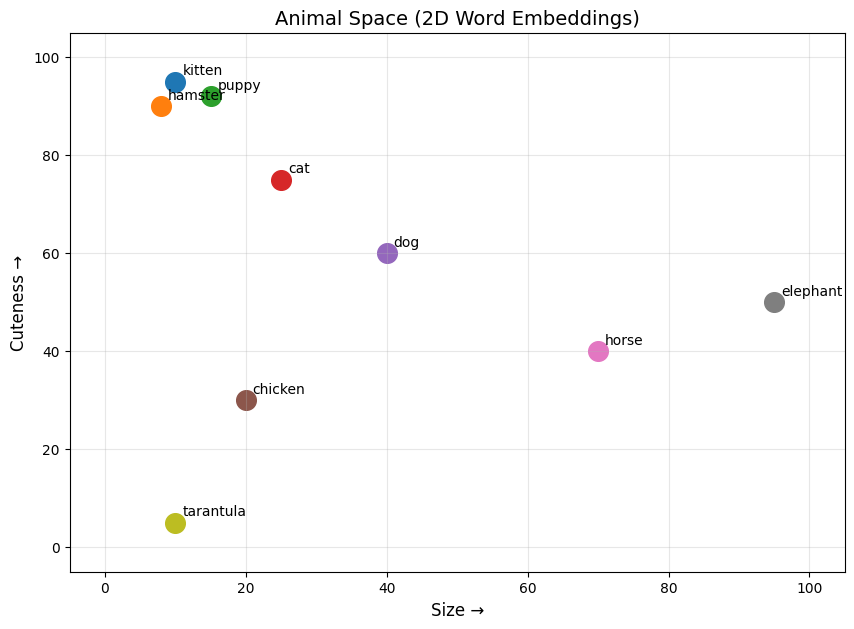

In [3]:
import matplotlib.pyplot as plt

animals = {
    'kitten': [95, 10],
    'hamster': [90, 8],
    'puppy': [92, 15],
    'cat': [75, 25],
    'dog': [60, 40],
    'chicken': [30, 20],
    'horse': [40, 70],
    'elephant': [50, 95],
    'tarantula': [5, 10]
}

# Plot animals
fig, ax = plt.subplots(figsize=(10, 7))
for animal, (cute, size) in animals.items():
    ax.scatter(size, cute, s=200)
    ax.annotate(animal, (size, cute), xytext=(5, 5), textcoords='offset points')

ax.set_xlabel('Size →', fontsize=12)
ax.set_ylabel('Cuteness →', fontsize=12)
ax.set_title('Animal Space (2D Word Embeddings)', fontsize=14)
ax.set_xlim(-5, 105)
ax.set_ylim(-5, 105)
ax.grid(True, alpha=0.3)
plt.show()

In this 2D space:
- **Kitten** and **hamster** are close (both small and cute)
- **Elephant** is isolated (very large, moderately cute)
- **Horse** is between small and large animals

### Vector Operations Reveal Semantic Relationships

The power of word embeddings comes from **vector arithmetic**. Remember the king-man example.


# Word2Vec and Encoder–Decoder Models

In [Lecture 8](lecture8_advanced-deep-learning.ipynb) we studied encoder–decoder architectures.

Word2Vec can be viewed as a very simple encoder–decoder model.

```text
Word
 ↓
Encoder
 ↓
Latent Representation
 ↓
Decoder
 ↓
Context Prediction
```



# Autoencoder vs Word2Vec

| Autoencoder | Word2Vec |
|------------|----------|
| Reconstructs input | Predicts context |
| Learns latent code | Learns word embedding |
| Input = target | Input ≠ target |
| Compression | Semantic representation |

The embedding vector plays a role similar to the latent representation in an autoencoder.


---
## Practical Examples with Pre-trained Models

### Loading Pre-trained Word Vectors

We'll use Gensim to load pre-trained word vectors. First, install the required package:

In [4]:
# Install gensim 
# !pip install gensim

import numpy as np
import gensim.downloader as api

c:\Users\m.amintoosi\.conda\envs\pth-gpu\lib\site-packages\google\api_core\_python_version_support.py:263: FutureWarning: You are using a Python version (3.10.16) which Google will stop supporting in new releases of google.api_core once it reaches its end of life (2026-10-04). Please upgrade to the latest Python version, or at least Python 3.11, to continue receiving updates for google.api_core past that date.
  warnings.warn(message, FutureWarning)


In [5]:
# Load pre-trained GloVe vectors (100-dimensional, trained on Wikipedia)
# This will download the model on first run (~128 MB)
print("Loading pre-trained word vectors...")
model = api.load("glove-wiki-gigaword-100")
print(f"Loaded {len(model.key_to_index):,} word vectors")

Loading pre-trained word vectors...
Loaded 400,000 word vectors


In [6]:
# Examine a word vector
print(f"Vector for 'king' (first 10 dimensions): {model['king'][:10]}")
print(f"Vector shape: {model['king'].shape}")

Vector for 'king' (first 10 dimensions): [-0.32307 -0.87616  0.21977  0.25268  0.22976  0.7388  -0.37954 -0.35307
 -0.84369 -1.1113 ]
Vector shape: (100,)


### Finding Similar Words

In [7]:
# Find the 10 most similar words to "king"
similar_to_king = model.most_similar("king", topn=5)

print("Words most similar to 'king':")
for word, similarity in similar_to_king:
    print(f"  {word:15} → {similarity:.4f}")

Words most similar to 'king':
  prince          → 0.7682
  queen           → 0.7508
  son             → 0.7021
  brother         → 0.6986
  monarch         → 0.6978


In [8]:
# Try with other words
for query_word in ["computer", "beautiful", "iran", "tehran"]:
    if query_word in model.key_to_index:
        print(f"\nWords similar to '{query_word}':")
        for word, sim in model.most_similar(query_word, topn=5):
            print(f"  {word:15} {sim:.4f}")
    else:
        print(f"'{query_word}' not in vocabulary")


Words similar to 'computer':
  computers       0.8752
  software        0.8373
  technology      0.7642
  pc              0.7366
  hardware        0.7290

Words similar to 'beautiful':
  lovely          0.8909
  gorgeous        0.8722
  wonderful       0.8081
  charming        0.7719
  magnificent     0.7332

Words similar to 'iran':
  tehran          0.8503
  iranian         0.7911
  syria           0.7800
  iraq            0.7679
  nuclear         0.7258

Words similar to 'tehran':
  iran            0.8503
  iranian         0.7557
  pyongyang       0.7014
  ahmadinejad     0.6929
  moscow          0.6898


### The Famous Analogy: King - Man + Woman = Queen

This is the most famous example of word vector arithmetic. The idea is:

> If we take the concept of "king," remove the "maleness," and add "femaleness," we should get "queen."

In [9]:
# The classic analogy: king - man + woman = ?
result = model.most_similar(positive=['king', 'woman'], negative=['man'], topn=5)

print("king - man + woman = ?")
print("-" * 40)
for word, similarity in result:
    print(f"  {word:15} → {similarity:.4f}")

king - man + woman = ?
----------------------------------------
  queen           → 0.7699
  monarch         → 0.6843
  throne          → 0.6756
  daughter        → 0.6595
  princess        → 0.6521


**Queen is the top result!** The vector arithmetic successfully captures the gender relationship.

### Understanding the Math Behind Analogies

In [10]:
def explain_analogy(word_a, word_b, word_c, model):
    """
    Analogy: word_a is to word_b as word_c is to ?
    
    Mathematically: ? ≈ word_b - word_a + word_c
    """
    # Get vectors
    vec_a = model[word_a]
    vec_b = model[word_b]
    vec_c = model[word_c]
    
    # Compute the target vector
    target_vec = vec_b - vec_a + vec_c
    
    # Find closest words
    results = model.most_similar(positive=[word_b, word_c], negative=[word_a], topn=5)
    
    print(f"Analogy: {word_a} is to {word_b} as {word_c} is to ?")
    print(f"\nMathematical operation:")
    print(f"  target = {word_b} - {word_a} + {word_c}")
    print(f"  target = {vec_b[:3]}... - {vec_a[:3]}... + {vec_c[:3]}...")
    print(f"  target = {target_vec[:3]}...")
    print(f"\nTop predictions:")
    for word, sim in results:
        print(f"  {word}: {sim:.4f}")
    
    return results

# Run the explanation
explain_analogy("man", "king", "woman", model)

Analogy: man is to king as woman is to ?

Mathematical operation:
  target = king - man + woman
  target = [-0.32307 -0.87616  0.21977]... - [0.37293 0.38503 0.71086]... + [0.59368 0.44825 0.5932 ]...
  target = [-0.10231996 -0.81294006  0.10211003]...

Top predictions:
  queen: 0.7699
  monarch: 0.6843
  throne: 0.6756
  daughter: 0.6595
  princess: 0.6521


[('queen', 0.7698540687561035),
 ('monarch', 0.6843381524085999),
 ('throne', 0.6755736470222473),
 ('daughter', 0.6594556570053101),
 ('princess', 0.6520534157752991)]

### More Analogy Examples

In [11]:
def run_analogy(positive, negative, topn=5):
    """Helper function to run analogies."""
    results = model.most_similar(positive=positive, negative=negative, topn=topn)
    formula = " + ".join(positive)
    if negative:
        formula += " - " + " - ".join(negative)
    print(f"{formula} = ?")
    for word, sim in results:
        print(f"  {word}: {sim:.4f}")
    print()

# Geographic analogies
print("=" * 50)
print("GEOGRAPHIC ANALOGIES")
print("=" * 50)
run_analogy(['paris', 'japan'], ['france'])
run_analogy(['tehran', 'germany'], ['iran'])

# Grammatical analogies
print("=" * 50)
print("GRAMMATICAL ANALOGIES")
print("=" * 50)
run_analogy(['walking', 'swim'], ['walk'])
run_analogy(['mice', 'dog'], ['mouse'])

# Semantic analogies
print("=" * 50)
print("SEMANTIC ANALOGIES")
print("=" * 50)
run_analogy(['summer', 'cold'], ['winter'])
run_analogy(['doctor', 'law'], ['hospital'])

GEOGRAPHIC ANALOGIES
paris + japan - france = ?
  tokyo: 0.8994
  osaka: 0.7421
  japanese: 0.7059
  seoul: 0.6949
  shanghai: 0.6679

tehran + germany - iran = ?
  berlin: 0.8361
  munich: 0.7773
  frankfurt: 0.7377
  cologne: 0.7185
  hamburg: 0.7169

GRAMMATICAL ANALOGIES


walking + swim - walk = ?
  swimming: 0.8009
  surfing: 0.6603
  swam: 0.6448
  rowing: 0.6413
  jogging: 0.6376

mice + dog - mouse = ?
  dogs: 0.8048
  rats: 0.7038
  cats: 0.6896
  animals: 0.6468
  horses: 0.6444

SEMANTIC ANALOGIES
summer + cold - winter = ?
  hot: 0.7388
  cool: 0.6947
  warm: 0.6855
  days: 0.6771
  turned: 0.6674

doctor + law - hospital = ?
  laws: 0.7347
  subject: 0.6480
  statute: 0.6445
  rules: 0.6442
  legal: 0.6344



### Finding the Odd One Out

In [12]:
# Find the word that doesn't belong
words_list1 = ["breakfast", "cereal", "dinner", "lunch"]
words_list2 = ["dog", "cat", "car", "fish"]
words_list3 = ["apple", "orange", "banana", "car"]

print("Which word doesn't belong?")
print(f"  {words_list1} → {model.doesnt_match(words_list1)}")
print(f"  {words_list2} → {model.doesnt_match(words_list2)}")
print(f"  {words_list3} → {model.doesnt_match(words_list3)}")

Which word doesn't belong?
  ['breakfast', 'cereal', 'dinner', 'lunch'] → cereal
  ['dog', 'cat', 'car', 'fish'] → car
  ['apple', 'orange', 'banana', 'car'] → car


### Computing Similarity Scores

In [13]:
# Compute similarity between word pairs
word_pairs = [
    ("king", "queen"),
    ("king", "man"),
    ("king", "apple"),
    ("dog", "puppy"),
    ("dog", "cat"),
    ("happy", "sad"),
    ("fast", "quick"),
    ("big", "small"),
]

print("Word Pair Similarities:")
print("-" * 45)
for w1, w2 in word_pairs:
    sim = model.similarity(w1, w2)
    print(f"  {w1:10} ↔ {w2:10} : {sim:.4f}")

Word Pair Similarities:
---------------------------------------------
  king       ↔ queen      : 0.7508
  king       ↔ man        : 0.5119
  king       ↔ apple      : 0.2668
  dog        ↔ puppy      : 0.7236
  dog        ↔ cat        : 0.8798
  happy      ↔ sad        : 0.6801
  fast       ↔ quick      : 0.7107
  big        ↔ small      : 0.7180


**Interesting observation**: Antonyms like "big" and "small" often have high similarity because they appear in similar contexts (e.g., "How big/small is it?"). This shows that word embeddings capture **distributional similarity**, not necessarily semantic similarity in the traditional sense.

### Simple Query: "Capital of Iran"

In [14]:
# Find the capital of Iran
# Logic: If paris is to france as X is to iran
# X = paris - france + iran

result = model.most_similar(positive=['paris', 'iran'], negative=['france'], topn=5)

print("Query: What is the capital of Iran?")
print("  paris - france + iran = ?")
print("-" * 40)
for word, sim in result:
    print(f"  {word}: {sim:.4f}")

Query: What is the capital of Iran?
  paris - france + iran = ?
----------------------------------------
  tehran: 0.8785
  iranian: 0.7055
  moscow: 0.6929
  seoul: 0.6468
  cairo: 0.6466


### Visualizing Word Relationships (t-SNE)

c:\Users\m.amintoosi\.conda\envs\pth-gpu\lib\site-packages\joblib\externals\loky\backend\context.py:136: UserWarning: Could not find the number of physical cores for the following reason:
[WinError 2] The system cannot find the file specified
Returning the number of logical cores instead. You can silence this warning by setting LOKY_MAX_CPU_COUNT to the number of cores you want to use.
  warnings.warn(
  File "c:\Users\m.amintoosi\.conda\envs\pth-gpu\lib\site-packages\joblib\externals\loky\backend\context.py", line 257, in _count_physical_cores
    cpu_info = subprocess.run(
  File "c:\Users\m.amintoosi\.conda\envs\pth-gpu\lib\subprocess.py", line 503, in run
    with Popen(*popenargs, **kwargs) as process:
  File "c:\Users\m.amintoosi\.conda\envs\pth-gpu\lib\subprocess.py", line 971, in __init__
    self._execute_child(args, executable, preexec_fn, close_fds,
  File "c:\Users\m.amintoosi\.conda\envs\pth-gpu\lib\subprocess.py", line 1456, in _execute_child
    hp, ht, pid, tid = _winap

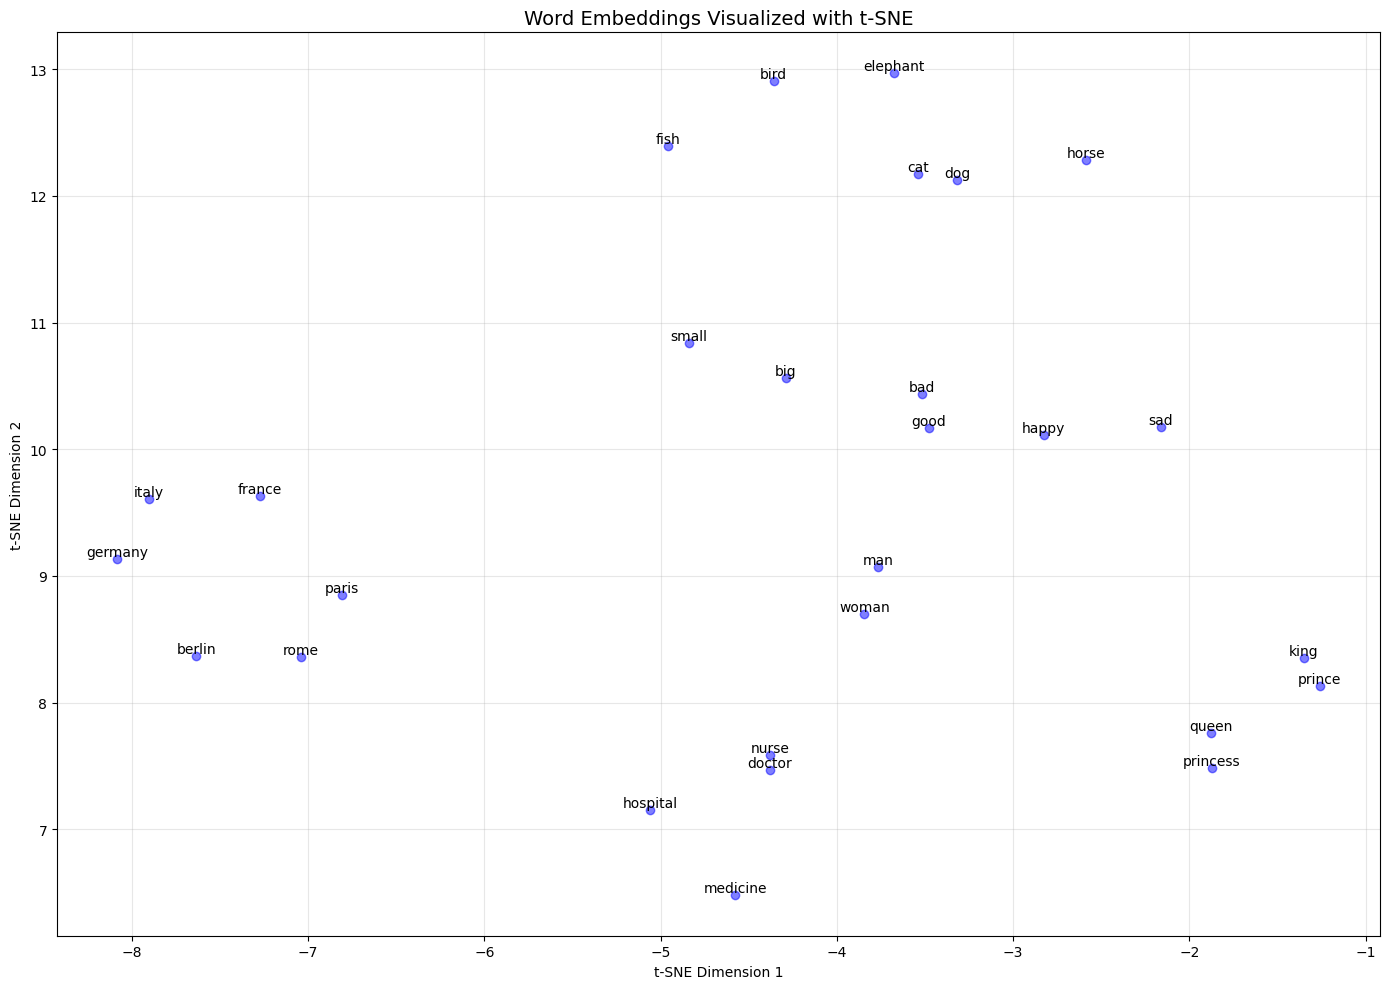

In [15]:
from sklearn.manifold import TSNE
import matplotlib.pyplot as plt

# Select interesting words
words_of_interest = [
    'king', 'queen', 'prince', 'princess', 'man', 'woman',
    'paris', 'france', 'berlin', 'germany', 'rome', 'italy',
    'cat', 'dog', 'fish', 'bird', 'horse', 'elephant',
    'good', 'bad', 'happy', 'sad', 'big', 'small',
    'doctor', 'nurse', 'hospital', 'medicine'
]

# Filter to words that exist in the model
words_of_interest = [w for w in words_of_interest if w in model.key_to_index]

# Get vectors for these words
word_vectors = np.array([model[w] for w in words_of_interest])

# Reduce to 2D using t-SNE
tsne = TSNE(n_components=2, random_state=42, perplexity=min(15, len(words_of_interest)-1))
word_vectors_2d = tsne.fit_transform(word_vectors)

# Plot
plt.figure(figsize=(14, 10))
plt.scatter(word_vectors_2d[:, 0], word_vectors_2d[:, 1], c='blue', alpha=0.5)

for i, word in enumerate(words_of_interest):
    plt.annotate(word, (word_vectors_2d[i, 0], word_vectors_2d[i, 1]), 
                 fontsize=10, ha='center', va='bottom')

plt.title("Word Embeddings Visualized with t-SNE", fontsize=14)
plt.xlabel("t-SNE Dimension 1")
plt.ylabel("t-SNE Dimension 2")
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

**Observations from the visualization:**
- Royalty words (king, queen, prince, princess) cluster together
- Country-capital pairs (paris-france, berlin-germany) are near each other
- Animals form their own cluster
- Antonyms (good-bad, happy-sad, big-small) are relatively close but in opposite directions


# Predicting Context

Consider:

```text
the cat sat on the mat
```

Window size = 2

Center word:

```text
sat
```

Context words:

```text
cat
on
the
mat
```


![](img/CBOW-Skip-Grampng.png)

[Source](https://serokell.io/blog/word2vec)


# Skip-Gram Training Examples

```text
(sat → cat)
(sat → on)
(sat → the)
(sat → mat)
```



# Skip-Gram Architecture


![SkipGram](img/skip_gram_net_arch.png)


[Source](https://mccormickml.com/2016/04/19/word2vec-tutorial-the-skip-gram-model/)



# Generating Training Examples


In [16]:

sentence = "Anne was beginning to get very tired".split()

window_size = 2

for i, center_word in enumerate(sentence):

    start = max(0, i-window_size)
    end = min(len(sentence), i+window_size+1)

    context = [
        sentence[j]
        for j in range(start, end)
        if j != i
    ]

    print(center_word, "->", context)


Anne -> ['was', 'beginning']
was -> ['Anne', 'beginning', 'to']
beginning -> ['Anne', 'was', 'to', 'get']
to -> ['was', 'beginning', 'get', 'very']
get -> ['beginning', 'to', 'very', 'tired']
very -> ['to', 'get', 'tired']
tired -> ['get', 'very']



For the center word **beginning**, the generated training pairs are:

```text
(beginning → Anne)
(beginning → was)
(beginning → to)
(beginning → get)
```



# Loading Anne of Green Gables

We now move from toy examples to a real corpus.

```text
data/Anne_of_Green_Gables.txt
```


In [17]:

from pathlib import Path
import re

corpus_path = Path("data/Anne_of_Green_Gables.txt")

text = corpus_path.read_text(
    encoding="utf-8"
)

text = text.lower()
text = re.sub(r"[^a-z\s]", " ", text)

tokens = text.split()

print("Number of tokens:", len(tokens))


Number of tokens: 107178


In [18]:

from collections import Counter

Counter(tokens).most_common(20)


[('the', 3926),
 ('and', 3398),
 ('i', 3265),
 ('to', 3046),
 ('a', 2229),
 ('it', 2099),
 ('of', 1923),
 ('you', 1702),
 ('she', 1519),
 ('in', 1479),
 ('that', 1371),
 ('was', 1364),
 ('her', 1315),
 ('anne', 1214),
 ('t', 1189),
 ('s', 1153),
 ('marilla', 851),
 ('but', 849),
 ('be', 822),
 ('as', 791)]


# Training Word2Vec with Gensim

Instead of implementing Word2Vec from scratch, we use a well-tested implementation.


In [19]:

from gensim.models import Word2Vec

sentences = [tokens]

model = Word2Vec(
    sentences=sentences,
    vector_size=100,
    window=5,
    min_count=5,
    sg=1,
    epochs=10
)



## Important Hyperparameters

- `vector_size` : embedding dimension
- `window` : context window size
- `min_count` : minimum frequency
- `sg=1` : Skip-Gram
- `sg=0` : CBOW



# Exploring the Learned Embeddings


In [20]:

model.wv.most_similar("anne", topn=5)


[('surprised', 0.9965387582778931),
 ('concert', 0.9963647127151489),
 ('confession', 0.9953275322914124),
 ('invited', 0.9946743249893188),
 ('school', 0.9944130778312683)]

In [21]:

model.wv.most_similar("marilla", topn=5)


[('herself', 0.993959903717041),
 ('head', 0.9935182332992554),
 ('door', 0.993461549282074),
 ('sorrel', 0.9931078553199768),
 ('came', 0.9930408000946045)]

In [22]:

model.wv.similarity("anne", "matthew")


0.9744315


# Analogy Tasks

The famous analogy examples can be tested using vector arithmetic.


In [24]:
# model.wv.most_similar(
#     positive=["king", "woman"],
#     negative=["man"],
#     topn=5
# )


Because *Anne of Green Gables* is relatively small, these analogies may not work. This is an important lesson:

> Better embeddings usually require larger corpora.



## Character Visualization

A particularly interesting activity is to visualize embeddings for:

- Anne
- Marilla
- Matthew
- Diana
- Gilbert
- Miss Stacy (Stacey)

and investigate whether characters with similar narrative roles cluster together.

![Miss-Stacey](img/Miss-Stacey.webp)
[Source](https://lainahastoomuchsparetime.wordpress.com/2021/02/19/anne-adaptations-anne-of-green-gables-1985-part-5/)

![Tomorrow is always fresh, with no mistakes in it](img/tomorrow.jpg)

[Figure Source](https://www.anneofgreengables.com/blog-posts/best-quotes-from-lucy-maud-montgomery)


# Pretrained Embeddings with spaCy

Our corpus is relatively small.

Modern NLP systems often use embeddings trained on billions of words.


In [26]:

# !pip install spacy
# !python -m spacy download en_core_web_md

import spacy

nlp = spacy.load("en_core_web_md")



Now let's revisit the examples from the beginning of the lecture.


In [27]:

nlp("king").similarity(nlp("queen"))


0.3825309165573663

In [28]:

nlp("man").similarity(nlp("woman"))


0.15610169391657686

In [29]:

nlp("paris").similarity(nlp("tehran"))


0.5575575739852713

In [30]:

nlp("cat").similarity(nlp("dog"))


1.0000000568192473

In [36]:
import spacy
import numpy as np

# Test if vectors are working
nlp = spacy.load("en_core_web_md")  # Must be md or lg!

# Quick sanity check
king_vec = nlp("king").vector
queen_vec = nlp("queen").vector

similarity = np.dot(king_vec, queen_vec) / (np.linalg.norm(king_vec) * np.linalg.norm(queen_vec))
print(f"King-Queen similarity: {similarity:.4f}")
print(f"Vector shape: {king_vec.shape}")

# This should output something like:
# King-Queen similarity: 0.6512
# Vector shape: (100,) or (300,)

King-Queen similarity: 0.3825
Vector shape: (300,)


In [37]:
import spacy
import numpy as np

# Load the model with vectors (must be md or lg)
try:
    nlp = spacy.load("en_core_web_md")
    print("Loaded en_core_web_md successfully!")
except OSError:
    print("Model not found. Download with: python -m spacy download en_core_web_md")
    exit()

def cosine_similarity(vec1, vec2):
    """Calculate cosine similarity between two vectors"""
    if np.linalg.norm(vec1) == 0 or np.linalg.norm(vec2) == 0:
        return 0
    return np.dot(vec1, vec2) / (np.linalg.norm(vec1) * np.linalg.norm(vec2))

def analogy(a, b, c, topn=5):
    """
    Solve analogy: a : b :: c : ?
    Example: man : king :: woman : queen
    """
    # Get word vectors
    vec_a = nlp(a).vector
    vec_b = nlp(b).vector
    vec_c = nlp(c).vector
    
    # Target vector: b - a + c
    target = vec_b - vec_a + vec_c
    
    # Find closest words
    results = []
    for token in nlp.vocab:
        # Filter: only real words with vectors
        if (token.has_vector and token.is_alpha and token.is_lower and 
            len(token.text) > 1 and token.text not in [a, b, c]):
            sim = cosine_similarity(target, token.vector)
            results.append((token.text, sim))
    
    results.sort(key=lambda x: x[1], reverse=True)
    return results[:topn]

def check_vector_quality():
    """Check if vectors are meaningful"""
    test_words = ["king", "queen", "man", "woman"]
    print("\nChecking vector quality:")
    print("-" * 40)
    
    for word in test_words:
        if nlp(word).has_vector:
            print(f"✓ '{word}' has vector (norm: {np.linalg.norm(nlp(word).vector):.2f})")
        else:
            print(f"✗ '{word}' has NO vector - using wrong model!")
    
    # Test basic similarity
    king_vec = nlp("king").vector
    queen_vec = nlp("queen").vector
    sim = cosine_similarity(king_vec, queen_vec)
    print(f"\nSimilarity between 'king' and 'queen': {sim:.4f}")
    print("(Should be ~0.6-0.7 for a good model)")

# First, check if vectors are working
check_vector_quality()

print("\n" + "="*60)
print("FAMOUS WORD ANALOGIES")
print("="*60)

# Test 1: King - Man + Woman
print("\n1. King : Man :: Queen : Woman")
print("-" * 40)
results = analogy("man", "king", "woman")
print(f"   Top result: {results[0][0]} (score: {results[0][1]:.4f})")
print(f"   Top 5 results: {[w for w, _ in results[:5]]}")

# Test 2: Paris - France + Germany
print("\n2. Paris : France :: Berlin : Germany")
print("-" * 40)
results = analogy("france", "paris", "germany")
print(f"   Top result: {results[0][0]} (score: {results[0][1]:.4f})")
print(f"   Top 5 results: {[w for w, _ in results[:5]]}")

# Test 3: Walking - Walk + Sleep
print("\n3. Walking : Walk :: Sleeping : Sleep")
print("-" * 40)
results = analogy("walk", "walking", "sleep")
print(f"   Top result: {results[0][0]} (score: {results[0][1]:.4f})")

# Test 4: Better - Good + Bad
print("\n4. Better : Good :: Worse : Bad")
print("-" * 40)
results = analogy("good", "better", "bad")
print(f"   Top result: {results[0][0]} (score: {results[0][1]:.4f})")

# Verification
print("\n" + "="*60)
print("VERIFYING THE RELATIONSHIP")
print("="*60)

vec_king = nlp("king").vector
vec_man = nlp("man").vector
vec_queen = nlp("queen").vector
vec_woman = nlp("woman").vector

vec1 = vec_king - vec_man
vec2 = vec_queen - vec_woman
similarity = cosine_similarity(vec1, vec2)
print(f"Similarity between (king - man) and (queen - woman): {similarity:.4f}")
print(f"Perfect analogy would be near 1.0, actual: {similarity:.4f}")

Loaded en_core_web_md successfully!

Checking vector quality:
----------------------------------------
✓ 'king' has vector (norm: 6.87)
✓ 'queen' has vector (norm: 7.02)
✓ 'man' has vector (norm: 7.14)
✓ 'woman' has vector (norm: 8.12)

Similarity between 'king' and 'queen': 0.3825
(Should be ~0.6-0.7 for a good model)

FAMOUS WORD ANALOGIES

1. King : Man :: Queen : Woman
----------------------------------------
   Top result: queen (score: 0.4812)
   Top 5 results: ['queen', 'll', 'got', 'has', 'lovin']

2. Paris : France :: Berlin : Germany
----------------------------------------
   Top result: co (score: 0.2790)
   Top 5 results: ['co', 've', 'woman', 'lovin', 'ol']

3. Walking : Walk :: Sleeping : Sleep
----------------------------------------
   Top result: had (score: 0.4569)

4. Better : Good :: Worse : Bad
----------------------------------------
   Top result: would (score: 1.0000)

VERIFYING THE RELATIONSHIP
Similarity between (king - man) and (queen - woman): 0.0146
Perfec


The pretrained spaCy vectors usually capture semantic relationships much better than embeddings trained on a single novel.


## Gensim vs spaCy

| Gensim | spaCy |
|---------|--------|
| Train embeddings | Usually uses pretrained embeddings |
| Educational & Research | Production NLP |
| Corpus-specific models | General-purpose models |
| Full control over training | Convenient & ready-to-use |
| Word2Vec, Doc2Vec, FastText | Word vectors, Contextual vectors |
| Excellent for word analogies | Not suitable for analogies |
| Requires large text corpus for training | Works out-of-box with small models |
| Lower-level access to vectors | Higher-level NLP pipeline |
| Best for topic modeling (LDA) | Best for NER, POS tagging, Dependency parsing |
| Slower inference | Optimized for speed |
| No built-in tokenization | Advanced tokenization & lemmatization |
| Manual preprocessing needed | Built-in preprocessing pipeline |
| Ideal for semantic similarity tasks | Ideal for syntactic & structural analysis |
| Models can be 1-3GB+ | Small models as low as 11MB |
| Community-driven | Industry-driven (Explosion AI) |
| Python + NumPy backend | Python + Cython backend (fast) |
| Great for custom embeddings | Great for transfer learning (spaCy transformers) |

## Additional Comparison Points

| Feature | Gensim | spaCy |
|---------|--------|-------|
| **Primary Use Case** | Unsupervised semantic modeling | Production-ready NLP pipeline |
| **Learning Curve** | Steeper (requires ML knowledge) | Gentle (API-focused) |
| **Documentation** | Academic-style | Industry/developer-friendly |
| **Pre-trained Models** | Many (GloVe, Word2Vec, FastText) | Fewer but high quality |
| **Multilingual Support** | Limited | Excellent (70+ languages) |
| **Training Speed** | Fast (optimized C routines) | Moderate |
| **Memory Usage** | High (full vectors in memory) | Low to moderate |
| **Batch Processing** | Excellent (streaming) | Good |
| **Integration** | Standalone | Integrates with DL frameworks |

## When to Use Which

| Scenario | Best Choice | Reason |
|----------|-------------|--------|
| **Word analogies** (king - man + woman) | Gensim | Built-in `most_similar()` with positive/negative |
| **Named Entity Recognition** | spaCy | State-of-the-art pre-trained NER |
| **Training custom word vectors** | Gensim | Full control over Word2Vec parameters |
| **Part-of-Speech tagging** | spaCy | Accurate out-of-box POS tagging |
| **Topic modeling** | Gensim | Native LDA, HDP, etc. |
| **Dependency parsing** | spaCy | Excellent syntactic parsing |
| **Large-scale document similarity** | Gensim | Memory-efficient similarity queries |
| **Quick NLP prototype** | spaCy | One-liner for common tasks |
| **Academic research on embeddings** | Gensim | Reproducible, parameter transparency |
| **Production API service** | spaCy | Fast, reliable, low latency |

## Code Example Comparison

```python
# GENSIM - Word embeddings & analogies
import gensim.downloader as api
model = api.load("glove-wiki-gigaword-300")
similarity = model.similarity("king", "queen")  # 0.65
result = model.most_similar(positive=["king", "woman"], negative=["man"])

# SPACY - NLP pipeline
import spacy
nlp = spacy.load("en_core_web_sm")
doc = nlp("Apple is looking to buy U.K. startup for $1 billion")
for ent in doc.ents:
    print(ent.label_, ent.text)  # ORG Apple, GPE U.K., MONEY $1 billion
```

## Performance Comparison

| Metric | Gensim | spaCy |
|--------|--------|-------|
| **Load time** (medium model) | 5-10 seconds | 2-3 seconds |
| **Inference speed** | Moderate | Fast |
| **Memory footprint** | 1-3 GB | 100 MB - 1 GB |
| **Training time** (1M sentences) | 10-30 minutes | N/A (uses pretrained) |

## Summary Recommendation

- **Use Gensim when**: You need word analogies, topic modeling, or training custom embeddings on your own corpus
- **Use spaCy when**: You need a complete NLP pipeline (NER, POS, parsing) for production applications
- **Use both when**: You want to extract features with spaCy and then train embeddings with Gensim



# From Word2Vec to Transformers

Word2Vec produces **static embeddings**.

```text
bank → one vector
```

regardless of context.



Place a figure in:


![Contextual Embeddings](img/contextual_mouse_transparent_1.png)
[Figure Source](https://ai.stanford.edu/blog/contextual/)



Consider:

```text
I deposited money in the bank.
```

```text
The fisherman sat by the bank.
```

Word2Vec:

```text
same vector
```

Transformer models (BERT, GPT, RoBERTa):

```text
different vectors
```

because the representation depends on context.



# Historical Perspective

```text
One-Hot Encoding
        ↓
Word2Vec
        ↓
GloVe
        ↓
FastText
        ↓
BERT
        ↓
GPT Embeddings
```



# Summary

In this notebook we:

- Motivated word embeddings using famous analogy examples.
- Studied the distributional hypothesis.
- Connected Word2Vec to encoder–decoder architectures.
- Learned Skip-Gram and CBOW.
- Generated training examples.
- Trained Word2Vec on *Anne of Green Gables*.
- Explored similarity and analogy queries.
- Visualized embeddings using t-SNE.
- Used pretrained embeddings with spaCy.
- Connected Word2Vec to modern transformer embeddings.

Word2Vec remains one of the most influential ideas in deep learning because it demonstrated that meaningful semantic representations can emerge from self-supervised prediction tasks.
